<a href="https://colab.research.google.com/github/Hajer5503/AgriSmart/blob/feature%2Firrigation-rl/modules/irrigation_rl/notebooks/02_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Irrigation RL — Data Preparation Pipeline
### From Raw ERA5 Data to RL-Ready Dataset
**Objective:** Autonomous Irrigation Optimization (Regression Simulator + RL Controller)

---

### What this notebook does

Starting from two raw ERA5 files, this notebook produces a single clean dataset  
ready to train the soil moisture simulator and RL irrigation agent.

| Step | Description |
|------|-------------|
| 1 | Load raw soil moisture & weather data |
| 2 | Merge and aggregate to daily resolution |
| 3 | Build wheat crop calendar & filter to active seasons |
| 4 | Compute day of season |
| 5 | Compute Kc (FAO-56, full 228-day season) & ETc |
| 6 | Rename columns to clean format |
| 7 | Create root-zone soil moisture `sm_root` |
| 8 | Estimate soil parameters (FC, WP, stress threshold) |
| 9 | Generate synthetic irrigation column |
| 10 | Compute `delta_sm` — the regression target |
| 11 | Final quality check & save |

**Input files:**
- `soil_moisture.csv` — hourly ERA5 soil moisture, multiple depth layers
- `weather.csv` — hourly ERA5 weather variables

**Output:** `rl_dataset_final.csv` + `soil_params.json`

---

> **Data source note:** Soil moisture and weather data are from ERA5 Land reanalysis  
> (Open-Meteo), representing a ~9km spatial grid cell over Tunisia. This is used  
> as a proxy for in-situ sensor data, which is standard practice in data-driven  
> irrigation research when field sensors are unavailable.

## 1.Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


## 2.Load Data

In [2]:
# ── Load soil moisture ────────────────────────────────────────────────────
soil = pd.read_csv("soil_moisture.csv", sep=";", skiprows=3)
soil.columns = soil.columns.str.strip()

print("Soil moisture columns:")
for c in soil.columns: print(f"  {c}")
print(f"Date range : {soil['time'].min()} → {soil['time'].max()}")
print(f"Rows       : {len(soil):,}")

Soil moisture columns:
  time
  soil_moisture_3_to_9cm (m³/m³)
  soil_moisture_0_to_1cm (m³/m³)
  soil_moisture_1_to_3cm (m³/m³)
  soil_moisture_9_to_27cm (m³/m³)
  soil_moisture_27_to_81cm (m³/m³)
Date range : 2022-11-16T08:00 → 2026-02-14T23:00
Rows       : 28,480


In [3]:
# ── Load weather ──────────────────────────────────────────────────────────
weather = pd.read_csv("weather.csv", sep=";", skiprows=3)
weather.columns = weather.columns.str.strip()

print("Weather columns:")
for c in weather.columns: print(f"  {c}")
print(f"Date range : {weather['time'].min()} → {weather['time'].max()}")
print(f"Rows       : {len(weather):,}")

Weather columns:
  time
  temperature_2m (°C)
  relative_humidity_2m (%)
  precipitation (mm)
  et0_fao_evapotranspiration (mm)
  wind_speed_10m (km/h)
Date range : 2021-03-23T00:00 → 2026-02-15T23:00
Rows       : 42,984


## 3. Merge & Aggregate to Daily Resolution

Both files are hourly. We:
1. Parse timestamps to datetime
2. Clip both to their common date range
3. Merge on timestamp
4. Aggregate to daily — **sum** for precipitation and ET0 (totals), **mean** for everything else

In [4]:
# ── Parse timestamps ──────────────────────────────────────────────────────
soil['time']    = pd.to_datetime(soil['time'])
weather['time'] = pd.to_datetime(weather['time'])

# ── Common date range ─────────────────────────────────────────────────────
start = max(soil['time'].min(), weather['time'].min())
end   = min(soil['time'].max(), weather['time'].max())

soil    = soil[(soil['time']       >= start) & (soil['time']       <= end)].reset_index(drop=True)
weather = weather[(weather['time'] >= start) & (weather['time']    <= end)].reset_index(drop=True)

print(f"Common date range : {start} → {end}")
print(f"Soil rows         : {len(soil):,}")
print(f"Weather rows      : {len(weather):,}")

Common date range : 2022-11-16 08:00:00 → 2026-02-14 23:00:00
Soil rows         : 28,480
Weather rows      : 28,480


In [5]:
# ── Merge on timestamp ────────────────────────────────────────────────────
merged = pd.merge(weather, soil, on='time', how='inner')
merged['date'] = merged['time'].dt.date

# ── Identify columns by role ───────────────────────────────────────────────
# Sum columns: precipitation and ET0 must be summed (they are rates → daily totals)
# Mean columns: temperatures, humidity, wind, soil moisture
sum_cols  = [c for c in merged.columns if 'precipitation' in c.lower()
                                        or 'et0' in c.lower()
                                        or 'evapotranspiration' in c.lower()]
mean_cols = [c for c in merged.columns if c not in sum_cols + ['time', 'date']
                                       and merged[c].dtype in ['float64', 'int64']]

agg_dict = {c: 'sum'  for c in sum_cols}
agg_dict.update({c: 'mean' for c in mean_cols})

daily = merged.groupby('date').agg(agg_dict).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(f"Daily rows : {len(daily)}")
print(f"Columns    : {daily.columns.tolist()}")
daily.head(3)

Daily rows : 1187
Columns    : ['date', 'precipitation (mm)', 'et0_fao_evapotranspiration (mm)', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'wind_speed_10m (km/h)', 'soil_moisture_3_to_9cm (m³/m³)', 'soil_moisture_0_to_1cm (m³/m³)', 'soil_moisture_1_to_3cm (m³/m³)', 'soil_moisture_9_to_27cm (m³/m³)', 'soil_moisture_27_to_81cm (m³/m³)']


,date,precipitation (mm),et0_fao_evapotranspiration (mm),temperature_2m (°C),relative_humidity_2m (%),wind_speed_10m (km/h),soil_moisture_3_to_9cm (m³/m³),soil_moisture_0_to_1cm (m³/m³),soil_moisture_1_to_3cm (m³/m³),soil_moisture_9_to_27cm (m³/m³),soil_moisture_27_to_81cm (m³/m³)
0,2022-11-16,0.3,2.53,21.818750,39.500000,4.556250,0.130188,0.083812,0.101562,0.178750,0.230000
1,2022-11-17,0.0,2.23,20.404167,56.666667,5.979167,0.129000,0.085500,0.099792,0.178000,0.229083
2,2022-11-18,0.0,3.23,20.700000,54.541667,8.512500,0.127000,0.084333,0.098917,0.176875,0.228000


## 4. Wheat Crop Calendar & Season Filtering

Wheat is a winter crop in Tunisia:
- **Sowing:** 1 November
- **Harvest:** 15 June (~228 days)

We define 4 complete seasons across the dataset and keep only days  
that fall within an active season. Days outside the crop season  
(summer fallow) are irrelevant for irrigation scheduling and are dropped.

In [6]:
# ── Define seasons ────────────────────────────────────────────────────────
crop_seasons = [
    {'year': 2022, 'sowing': '2022-11-01', 'harvest': '2023-06-15'},
    {'year': 2023, 'sowing': '2023-11-01', 'harvest': '2024-06-15'},
    {'year': 2024, 'sowing': '2024-11-01', 'harvest': '2025-06-15'},
    {'year': 2025, 'sowing': '2025-11-01', 'harvest': '2026-06-15'},
]

for s in crop_seasons:
    s['sowing']  = pd.to_datetime(s['sowing'])
    s['harvest'] = pd.to_datetime(s['harvest'])

# ── Build a list of all active crop days ──────────────────────────────────
active_dates = []
for s in crop_seasons:
    active_dates.extend(pd.date_range(s['sowing'], s['harvest'], freq='D'))

active_df = pd.DataFrame({'date': active_dates})

# ── Filter daily data to crop-active days only ─────────────────────────────
df = pd.merge(active_df, daily, on='date', how='inner').reset_index(drop=True)

print(f"Total active season days : {len(active_df)}")
print(f"Days with data           : {len(df)}")
print(f"Date range               : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Seasons covered          :")
for s in crop_seasons:
    n = len(df[(df['date'] >= s['sowing']) & (df['date'] <= s['harvest'])])
    print(f"  {s['year']} season: {n} days")

Total active season days : 909
Days with data           : 773
Date range               : 2022-11-16 → 2026-02-14
Seasons covered          :
  2022 season: 212 days
  2023 season: 228 days
  2024 season: 227 days
  2025 season: 106 days


## 5. Compute Day of Season

For each date, compute how many days have elapsed since sowing.  
Day 1 = sowing date. This is the index the Kc function uses.

In [7]:
def get_day_of_season(date):
    """Returns day number within the current wheat season (1 = sowing day)."""
    for s in crop_seasons:
        if s['sowing'] <= date <= s['harvest']:
            return (date - s['sowing']).days + 1
    return np.nan

df['day_of_season'] = df['date'].apply(get_day_of_season).astype(int)

print(f"Day of season range : {df['day_of_season'].min()} → {df['day_of_season'].max()}")
print(f"(Wheat season length: 228 days = Nov 1 → Jun 15)")

Day of season range : 1 → 228
(Wheat season length: 228 days = Nov 1 → Jun 15)


## 6. Kc and ETc (FAO-56, Full 228-Day Season)

Crop coefficient (Kc) follows the FAO-56 piecewise linear curve across  
five growth stages for the full 228-day wheat season.

The key fix from earlier exploration: the season runs to **day 228**, not day 150.  
Stopping at day 150 left ~30% of rows with NaN Kc. The corrected function  
adds the end-of-season maturation stage (days 150–228).

```
Stage          Days       Kc
─────────────────────────────────────────
Initial        1  →  20  0.70  (flat)
Development    20 →  50  0.70 → 1.15
Mid-season     50 → 100  1.15  (flat)
Late-season   100 → 175  1.15 → 0.35
End/maturity  175 → 228  0.35  (flat)
```

ETc (crop evapotranspiration) = ET0 × Kc

In [8]:
# ── FAO-56 Kc function — full 228-day season ──────────────────────────────
KC_BREAKPOINTS = [
    (1,   0.70),
    (20,  0.70),
    (50,  1.15),
    (100, 1.15),
    (175, 0.35),
    (228, 0.35),
]

def calculate_kc(day):
    """FAO-56 wheat Kc via linear interpolation between stage breakpoints."""
    if pd.isna(day):
        return np.nan
    day = int(day)
    if day <= KC_BREAKPOINTS[0][0]:  return KC_BREAKPOINTS[0][1]
    if day >= KC_BREAKPOINTS[-1][0]: return KC_BREAKPOINTS[-1][1]
    for i in range(len(KC_BREAKPOINTS) - 1):
        d0, kc0 = KC_BREAKPOINTS[i]
        d1, kc1 = KC_BREAKPOINTS[i + 1]
        if d0 <= day <= d1:
            t = (day - d0) / (d1 - d0)
            return round(kc0 + t * (kc1 - kc0), 4)
    return np.nan

# ── Identify ET0 column (handles different naming conventions) ─────────────
et0_col = next((c for c in df.columns if 'et0' in c.lower()
                or 'evapotranspiration' in c.lower()), None)
print(f"ET0 column identified : '{et0_col}'")

df['kc']     = df['day_of_season'].apply(calculate_kc)
df['etc_mm'] = (df[et0_col] * df['kc']).round(4)

print(f"NaN Kc rows  : {df['kc'].isna().sum()}  (should be 0)")
print(f"Kc range     : [{df['kc'].min():.3f}, {df['kc'].max():.3f}]")
print(f"ETc range    : [{df['etc_mm'].min():.3f}, {df['etc_mm'].max():.3f}] mm/day")

ET0 column identified : 'et0_fao_evapotranspiration (mm)'
NaN Kc rows  : 0  (should be 0)
Kc range     : [0.350, 1.150]
ETc range    : [0.420, 5.753] mm/day


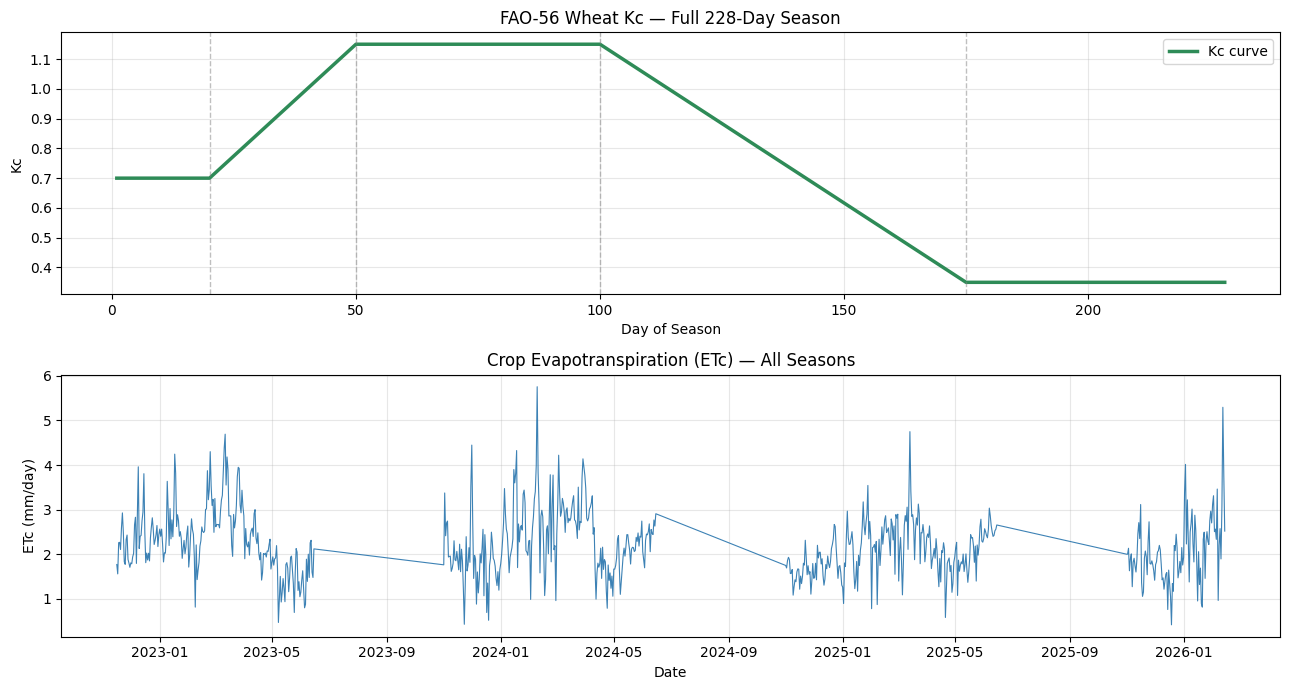

✅ Saved: 01_kc_etc.png


In [9]:
# ── Visualise Kc curve ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

days      = range(1, 229)
kc_curve  = [calculate_kc(d) for d in days]
stage_bounds = [20, 50, 100, 175]

axes[0].plot(days, kc_curve, color="#2E8B57", linewidth=2.5, label="Kc curve")
for b in stage_bounds:
    axes[0].axvline(b, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[0].set_xlabel("Day of Season")
axes[0].set_ylabel("Kc")
axes[0].set_title("FAO-56 Wheat Kc — Full 228-Day Season")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df["date"], df["etc_mm"], color="#1B6CA8", linewidth=0.8, alpha=0.85)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("ETc (mm/day)")
axes[1].set_title("Crop Evapotranspiration (ETc) — All Seasons")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("01_kc_etc.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved: 01_kc_etc.png")

## 7. — Rename Columns to Clean Format

Raw ERA5 column names contain units, special characters, and encoding  
artifacts (e.g., `temperature_2m (Â°C)`). We rename to short, clean,  
snake_case names that are safe for all downstream use.

In [10]:
# ── Build rename map dynamically (handles encoding variants) ─────────────
rename_map = {}

for col in df.columns:
    cl = col.lower()
    if 'precipitation' in cl:            rename_map[col] = 'precip_mm'
    elif 'et0' in cl or 'evapotrans' in cl: rename_map[col] = 'et0_mm'
    elif 'temperature_2m' in cl and 'max' not in cl and 'min' not in cl:
                                          rename_map[col] = 'temp_c'
    elif 'humidity' in cl:               rename_map[col] = 'rh_pct'
    elif 'wind_speed_10m' in cl:         rename_map[col] = 'wind_kmh'
    elif '9_to_27' in col or '9_27' in col:  rename_map[col] = 'sm_shallow'
    elif '27_to_81' in col or '27_81' in col: rename_map[col] = 'sm_deep'

df = df.rename(columns=rename_map)

print("Renamed columns:")
for old, new in rename_map.items():
    print(f"  '{old}'  →  '{new}'")

print(f"\nAll columns now: {df.columns.tolist()}")

Renamed columns:
  'precipitation (mm)'  →  'precip_mm'
  'et0_fao_evapotranspiration (mm)'  →  'et0_mm'
  'temperature_2m (°C)'  →  'temp_c'
  'relative_humidity_2m (%)'  →  'rh_pct'
  'wind_speed_10m (km/h)'  →  'wind_kmh'
  'soil_moisture_9_to_27cm (m³/m³)'  →  'sm_shallow'
  'soil_moisture_27_to_81cm (m³/m³)'  →  'sm_deep'

All columns now: ['date', 'precip_mm', 'et0_mm', 'temp_c', 'rh_pct', 'wind_kmh', 'soil_moisture_3_to_9cm (m³/m³)', 'soil_moisture_0_to_1cm (m³/m³)', 'soil_moisture_1_to_3cm (m³/m³)', 'sm_shallow', 'sm_deep', 'day_of_season', 'kc', 'etc_mm']


## 8. Create Root-Zone Soil Moisture (`sm_root`)

The RL agent needs **one** soil moisture state variable. The dataset contains  
multiple depth layers. We combine the two agronomically relevant layers for wheat  
(9–27cm and 27–81cm) into a single root-zone variable using a weighted average.

More weight is given to the shallow layer (9–27cm) where wheat roots are most  
active and where irrigation water primarily enters the soil.

```
sm_root = 0.6 × sm_shallow (9–27cm) + 0.4 × sm_deep (27–81cm)
```

sm_root range : [0.1511, 0.3037] m³/m³
sm_root mean  : 0.1980 m³/m³


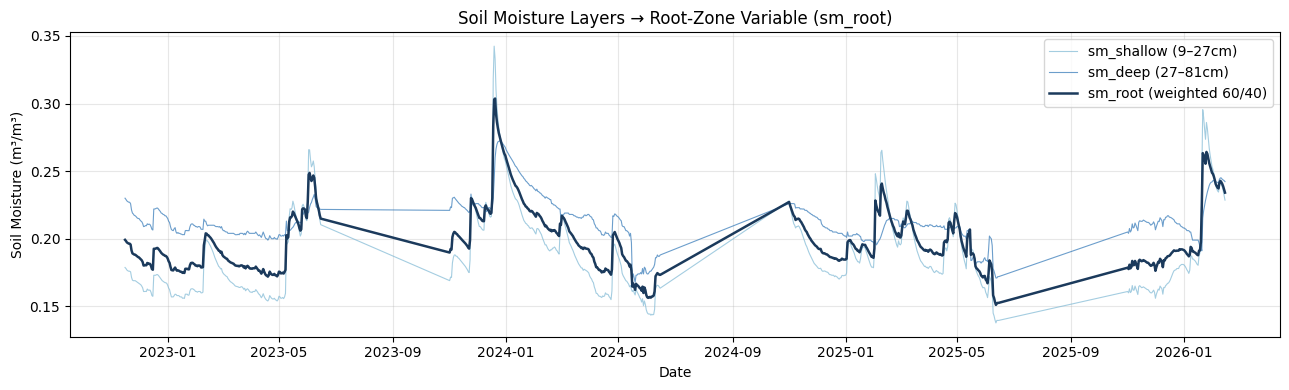

✅ Saved: 02_sm_root.png


In [11]:
W_SHALLOW = 0.6
W_DEEP    = 0.4

df['sm_root'] = (W_SHALLOW * df['sm_shallow'] + W_DEEP * df['sm_deep']).round(4)

print(f"sm_root range : [{df['sm_root'].min():.4f}, {df['sm_root'].max():.4f}] m³/m³")
print(f"sm_root mean  : {df['sm_root'].mean():.4f} m³/m³")

# Visualise
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['sm_shallow'], color='#7EB8D4', linewidth=0.8, alpha=0.7, label='sm_shallow (9–27cm)')
ax.plot(df['date'], df['sm_deep'],   color='#2E75B6', linewidth=0.8, alpha=0.7, label='sm_deep (27–81cm)')
ax.plot(df['date'], df['sm_root'],   color='#1B3A5C', linewidth=1.8, label='sm_root (weighted 60/40)')
ax.set_xlabel('Date'); ax.set_ylabel('Soil Moisture (m³/m³)')
ax.set_title('Soil Moisture Layers → Root-Zone Variable (sm_root)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_sm_root.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_sm_root.png")

## 9. Estimate Soil Parameters (FC, WP, Threshold)

Since soil type data is unavailable for this site, Field Capacity (FC)  
and Wilting Point (WP) are estimated from the statistical distribution  
of observed `sm_root`. This approach is accepted in data-driven  
irrigation research when in-situ soil characterization is absent.

- **FC (Field Capacity):** 95th percentile — the upper bound of observed moisture  
- **WP (Wilting Point):** 5th percentile — the lower safe bound before stress  
- **MAD = 40%** — Management Allowed Depletion, FAO-56 standard for wheat  
- **Stress Threshold:** the moisture level at which irrigation is triggered

```
AW        = FC − WP
Threshold = FC − (MAD × AW)
```

In [12]:
FC        = round(df['sm_root'].quantile(0.95), 4)
WP        = round(df['sm_root'].quantile(0.05), 4)
MAD       = 0.40
AW        = round(FC - WP, 4)
THRESHOLD = round(FC - (MAD * AW), 4)

print("=" * 44)
print("  SOIL PARAMETERS (derived from data)")
print("=" * 44)
print(f"  Field Capacity (FC)    : {FC:.4f} m³/m³")
print(f"  Wilting Point (WP)     : {WP:.4f} m³/m³")
print(f"  Available Water (AW)   : {AW:.4f} m³/m³")
print(f"  MAD                    : {MAD*100:.0f}%")
print(f"  Stress Threshold       : {THRESHOLD:.4f} m³/m³")
print("=" * 44)
print(f"\n  → Irrigate when sm_root < {THRESHOLD:.4f}")
print(f"  → Soil 'full' at       {FC:.4f}")
print(f"  → Danger below         {WP:.4f}")

  SOIL PARAMETERS (derived from data)
  Field Capacity (FC)    : 0.2447 m³/m³
  Wilting Point (WP)     : 0.1723 m³/m³
  Available Water (AW)   : 0.0724 m³/m³
  MAD                    : 40%
  Stress Threshold       : 0.2157 m³/m³

  → Irrigate when sm_root < 0.2157
  → Soil 'full' at       0.2447
  → Danger below         0.1723


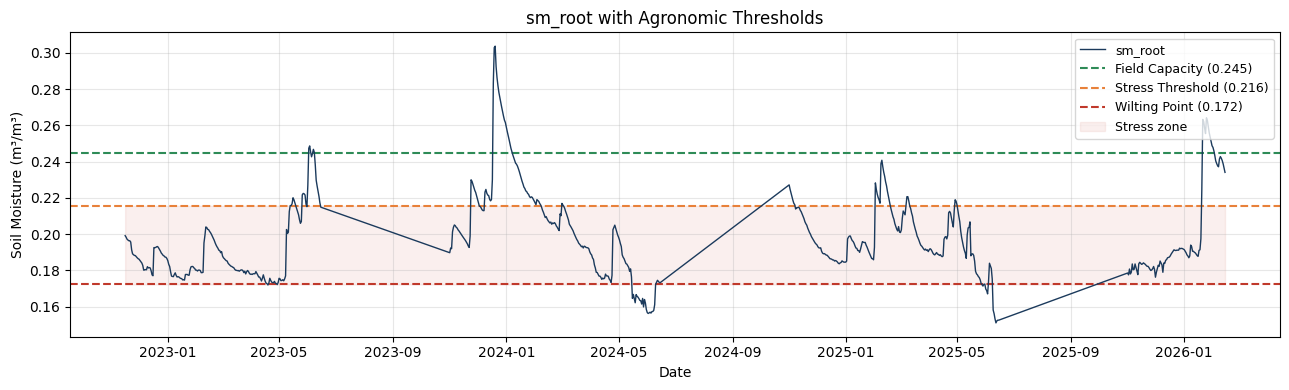

✅ Saved: 03_sm_thresholds.png


In [13]:
# ── Visualise thresholds on sm_root ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df['date'], df['sm_root'], color='#1B3A5C', linewidth=1.0, label='sm_root', zorder=3)
ax.axhline(FC,        color='#2E8B57', linestyle='--', linewidth=1.5, label=f'Field Capacity ({FC:.3f})')
ax.axhline(THRESHOLD, color='#E8813A', linestyle='--', linewidth=1.5, label=f'Stress Threshold ({THRESHOLD:.3f})')
ax.axhline(WP,        color='#C0392B', linestyle='--', linewidth=1.5, label=f'Wilting Point ({WP:.3f})')
ax.fill_between(df['date'], WP, THRESHOLD, alpha=0.08, color='#C0392B', label='Stress zone')

ax.set_xlabel('Date'); ax.set_ylabel('Soil Moisture (m³/m³)')
ax.set_title('sm_root with Agronomic Thresholds')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_sm_thresholds.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_sm_thresholds.png")

## 10. Generate Synthetic Irrigation Column

The regression simulator must learn:
> *"Given soil moisture, weather, and irrigation → how will soil moisture change tomorrow?"*

For this, **irrigation must be an input feature** in the training data.  
ERA5 data does not contain irrigation records, so a synthetic schedule  
is generated using the FAO-56 deficit-based scheduling rule.

This is not fabricated data — it is a physically grounded agronomic rule  
that produces a realistic irrigation history consistent with the observed  
soil moisture range. This approach is standard in data-driven irrigation research.

**Rule:**
```
If sm_root < THRESHOLD  AND  precipitation < 2mm:
    irrigation = ETc + soil_deficit    [capped at 20mm/day]
Else:
    irrigation = 0
```

The 2mm rain threshold avoids irrigating on days with meaningful natural rainfall.  
The 20mm/day cap represents a realistic physical limit for drip/sprinkler systems.

In [14]:
MAX_IRR_MM = 20.0   # realistic daily maximum for wheat irrigation

irrigation_mm = []

for i in range(len(df)):
    sm   = df.loc[i, 'sm_root']
    rain = df.loc[i, 'precip_mm']
    etc  = df.loc[i, 'etc_mm']

    if (sm < THRESHOLD) and (rain < 2.0):
        deficit = max(0.0, FC - sm)
        irr = min(etc + deficit, MAX_IRR_MM)
    else:
        irr = 0.0

    irrigation_mm.append(round(irr, 4))

df['irrigation_mm']  = irrigation_mm
df['net_balance_mm'] = (df['precip_mm'] + df['irrigation_mm'] - df['etc_mm']).round(4)

days_irr    = (df['irrigation_mm'] > 0).sum()
total_water = df['irrigation_mm'].sum()

print(f"Days with irrigation   : {days_irr} / {len(df)}")
print(f"Total water applied    : {total_water:.1f} mm (all seasons combined)")
print(f"Average per season     : {total_water / 4:.1f} mm")
print(f"Max single irrigation  : {df['irrigation_mm'].max():.2f} mm")

Days with irrigation   : 571 / 773
Total water applied    : 1340.3 mm (all seasons combined)
Average per season     : 335.1 mm
Max single irrigation  : 5.78 mm


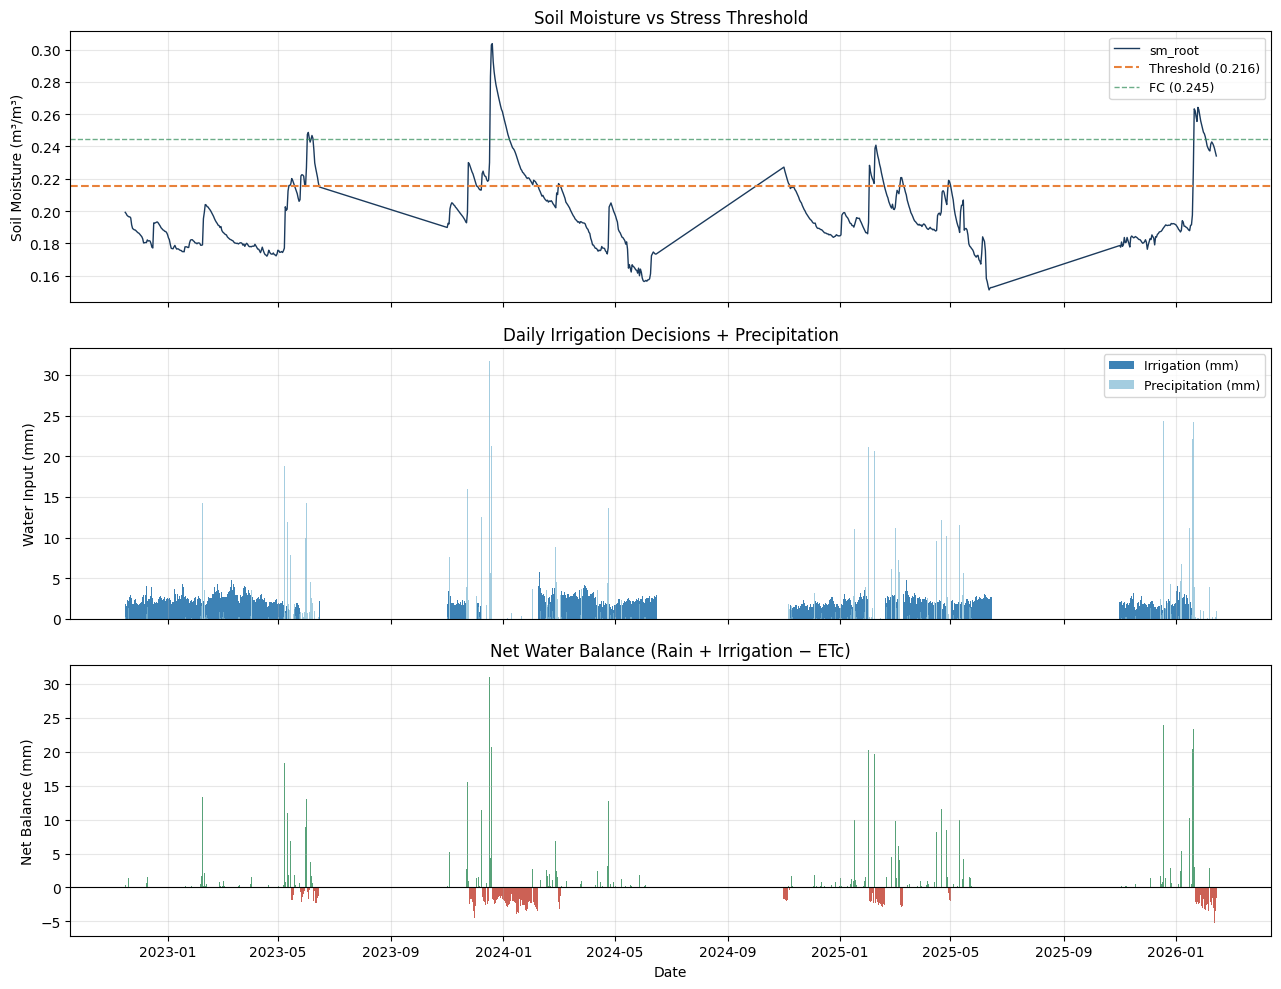

✅ Saved: 04_irrigation.png


In [15]:
# ── Visualise irrigation decisions ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(df['date'], df['sm_root'], color='#1B3A5C', linewidth=1.0, label='sm_root')
axes[0].axhline(THRESHOLD, color='#E8813A', linestyle='--', linewidth=1.5, label=f'Threshold ({THRESHOLD:.3f})')
axes[0].axhline(FC,        color='#2E8B57', linestyle='--', linewidth=1.0, label=f'FC ({FC:.3f})', alpha=0.7)
axes[0].set_ylabel('Soil Moisture (m³/m³)')
axes[0].set_title('Soil Moisture vs Stress Threshold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].bar(df['date'], df['irrigation_mm'], color='#1B6CA8', alpha=0.85, width=1, label='Irrigation (mm)')
axes[1].bar(df['date'], df['precip_mm'],     color='#7EB8D4', alpha=0.70, width=1, label='Precipitation (mm)')
axes[1].set_ylabel('Water Input (mm)')
axes[1].set_title('Daily Irrigation Decisions + Precipitation')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

colors = ['#2E8B57' if v >= 0 else '#C0392B' for v in df['net_balance_mm']]
axes[2].bar(df['date'], df['net_balance_mm'], color=colors, width=1, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('Net Balance (mm)')
axes[2].set_xlabel('Date')
axes[2].set_title('Net Water Balance (Rain + Irrigation − ETc)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_irrigation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_irrigation.png")

## 11. Compute `delta_sm` (Regression Target)

The regression simulator will learn to predict the **daily change** in  
root-zone soil moisture — not the absolute value.

Predicting change (delta) is more stable than predicting absolute moisture  
because the model only needs to capture what drives moisture up or down  
rather than learning the full absolute range.

```
delta_sm(t) = sm_root(t+1) − sm_root(t)
```

The last row of each season has no "tomorrow" — it is dropped after computation.

In [16]:
df['delta_sm'] = (df['sm_root'].shift(-1) - df['sm_root']).round(6)

# Drop the last row — it has no next-day moisture value
df = df.iloc[:-1].reset_index(drop=True)

print(f"Rows after computing delta_sm : {len(df)}")
print(f"delta_sm range : [{df['delta_sm'].min():.5f}, {df['delta_sm'].max():.5f}]")
print(f"delta_sm mean  : {df['delta_sm'].mean():.5f}")
print(f"delta_sm std   : {df['delta_sm'].std():.5f}")

Rows after computing delta_sm : 772
delta_sm range : [-0.02510, 0.05390]
delta_sm mean  : 0.00005
delta_sm std   : 0.00506


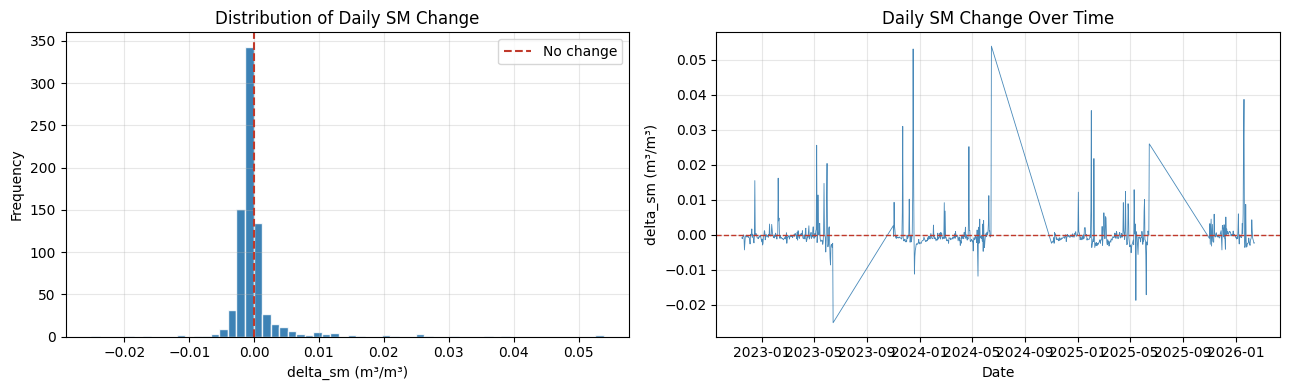

✅ Saved: 05_delta_sm.png


In [17]:
# ── Visualise delta_sm ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['delta_sm'], bins=60, color='#1B6CA8', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='#C0392B', linewidth=1.5, linestyle='--', label='No change')
axes[0].set_xlabel('delta_sm (m³/m³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily SM Change')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df['date'], df['delta_sm'], color='#1B6CA8', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='#C0392B', linewidth=1.0, linestyle='--')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('delta_sm (m³/m³)')
axes[1].set_title('Daily SM Change Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_delta_sm.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: 05_delta_sm.png")

## 12. Final Column Structure, Quality Check & Save

We select the final columns in a logical order, clearly grouped by their role  
in the regression-RL pipeline, then run a quality check before saving.

In [18]:
# ── Final column order ────────────────────────────────────────────────────
final_cols = [
    # Identifiers
    'date',
    'day_of_season',

    # Weather inputs (exogenous — nature, not controlled)
    'precip_mm',
    'et0_mm',
    'temp_c',
    'rh_pct',
    'wind_kmh',

    # Crop parameters
    'kc',
    'etc_mm',

    # Soil moisture state
    'sm_shallow',
    'sm_deep',
    'sm_root',          # ← main RL state variable

    # Action (what the RL agent controls)
    'irrigation_mm',    # ← input to regression simulator

    # Derived physics
    'net_balance_mm',   # rain + irrigation - ETc

    # Regression target
    'delta_sm',         # ← what the simulator predicts
]

final_cols = [c for c in final_cols if c in df.columns]
df_final   = df[final_cols].copy()

print(f"Final shape : {df_final.shape}")
print(f"Columns ({len(final_cols)}):")
for i, c in enumerate(final_cols, 1):
    print(f"  {i:2d}. {c}")

Final shape : (772, 15)
Columns (15):
   1. date
   2. day_of_season
   3. precip_mm
   4. et0_mm
   5. temp_c
   6. rh_pct
   7. wind_kmh
   8. kc
   9. etc_mm
  10. sm_shallow
  11. sm_deep
  12. sm_root
  13. irrigation_mm
  14. net_balance_mm
  15. delta_sm


In [19]:
# ── Quality check ─────────────────────────────────────────────────────────
print("=" * 50)
print("  FINAL DATASET — QUALITY REPORT")
print("=" * 50)

print(f"\n📊 Shape      : {df_final.shape}")
print(f"📅 Date range : {df_final['date'].min().date()} → {df_final['date'].max().date()}")

nulls = df_final.isnull().sum()
print("\n🔍 Missing values:")
if nulls.sum() == 0:
    print("  ✅ None")
else:
    print(nulls[nulls > 0])

print("\n📆 Rows per season year:")
for yr, cnt in df_final['date'].dt.year.value_counts().sort_index().items():
    print(f"  {yr}: {cnt} days")

print("\n📊 Key statistics:")
stats = ['sm_root','etc_mm','precip_mm','irrigation_mm','net_balance_mm','delta_sm']
print(df_final[stats].describe().round(4).to_string())

  FINAL DATASET — QUALITY REPORT

📊 Shape      : (772, 15)
📅 Date range : 2022-11-16 → 2026-02-13

🔍 Missing values:
  ✅ None

📆 Rows per season year:
  2022: 46 days
  2023: 227 days
  2024: 228 days
  2025: 227 days
  2026: 44 days

📊 Key statistics:
        sm_root    etc_mm  precip_mm  irrigation_mm  net_balance_mm  delta_sm
count  772.0000  772.0000   772.0000       772.0000        772.0000  772.0000
mean     0.1980    2.2111     0.8259         1.7361          0.3509    0.0000
std      0.0235    0.7178     3.0689         1.1771          3.0829    0.0051
min      0.1511    0.4200     0.0000         0.0000         -5.2929   -0.0251
25%      0.1816    1.7594     0.0000         0.0000          0.0418   -0.0014
50%      0.1922    2.1505     0.0000         1.9728          0.0593   -0.0007
75%      0.2108    2.6130     0.1000         2.5418          0.0817    0.0001
max      0.3037    5.7535    31.7000         5.7849         31.0038    0.0539


In [20]:
# ── Save dataset ──────────────────────────────────────────────────────────
df_final.to_csv('rl_dataset_final.csv', index=False, sep=';')
print("✅ Saved: rl_dataset_final.csv")

# ── Save soil parameters as reference ─────────────────────────────────────
soil_params = {
    'field_capacity'        : FC,
    'wilting_point'         : WP,
    'available_water'       : AW,
    'mad_fraction'          : MAD,
    'stress_threshold'      : THRESHOLD,
    'shallow_weight'        : W_SHALLOW,
    'deep_weight'           : W_DEEP,
    'max_irrigation_mm_day' : MAX_IRR_MM,
}
with open('soil_params.json', 'w') as f:
    json.dump(soil_params, f, indent=2)
print("✅ Saved: soil_params.json")

print()
print("Files produced:")
print("  rl_dataset_final.csv   — main RL dataset (regression + RL training)")
print("  soil_params.json       — soil constants (FC, WP, threshold)")
print("  01_kc_etc.png          — Kc curve + ETc time series")
print("  02_sm_root.png         — soil moisture layers")
print("  03_sm_thresholds.png   — thresholds on sm_root")
print("  04_irrigation.png      — irrigation decisions")
print("  05_delta_sm.png        — delta_sm distribution")

✅ Saved: rl_dataset_final.csv
✅ Saved: soil_params.json

Files produced:
  rl_dataset_final.csv   — main RL dataset (regression + RL training)
  soil_params.json       — soil constants (FC, WP, threshold)
  01_kc_etc.png          — Kc curve + ETc time series
  02_sm_root.png         — soil moisture layers
  03_sm_thresholds.png   — thresholds on sm_root
  04_irrigation.png      — irrigation decisions
  05_delta_sm.png        — delta_sm distribution


In [21]:
from google.colab import files
files.download('rl_dataset_final.csv')
files.download('soil_params.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Summary

| Step | What was done | Key output |
|------|--------------|------------|
| 1 | Loaded raw ERA5 hourly files | `soil`, `weather` DataFrames |
| 2 | Merged on timestamp, aggregated to daily | `daily` — 1 row per day |
| 3 | Defined wheat crop calendar, filtered to active season days | 4 seasons × ~228 days each |
| 4 | Computed day-of-season index | `day_of_season` (1–228) |
| 5 | Computed FAO-56 Kc (full 228-day curve) and ETc | `kc`, `etc_mm` |
| 6 | Renamed all columns to clean snake_case | No encoding artifacts |
| 7 | Created `sm_root` — weighted average of two SM layers | `sm_root` |
| 8 | Estimated FC, WP, stress threshold from data | `soil_params.json` |
| 9 | Generated synthetic irrigation via FAO-56 deficit rule | `irrigation_mm`, `net_balance_mm` |
| 10 | Computed `delta_sm` — daily change in root-zone moisture | `delta_sm` (regression target) |
| 11 | Final quality check, saved dataset | `rl_dataset_final.csv` |

---

### What the regression simulator will learn (next notebook)

```
delta_sm = f(
    sm_root,          # current soil moisture state
    precip_mm,        # rainfall today
    et0_mm,           # atmospheric evaporative demand
    kc,               # crop growth stage
    temp_c,           # temperature
    irrigation_mm,    # ← the action being optimized
    net_balance_mm    # total water budget
)
```

Once trained, this model becomes the simulated farm environment  
inside which the RL agent learns its optimal irrigation policy.

---
*Reference: Allen, R.G., Pereira, L.S., Raes, D., Smith, M. (1998).  
Crop evapotranspiration — FAO Irrigation and Drainage Paper 56. FAO, Rome.*